# K-shell Algorithm

This file is an experiment to verify the stability of the K-shell algorithm.

Before running this program, please make sure to run Topic_Modeling.ipynb to generate the necessary intermediate files.

In [5]:
import os
import json
import random
import numpy as np
import networkx as nx
from collections import defaultdict, Counter
from itertools import combinations
from multiprocessing import Pool, cpu_count
import matplotlib.pyplot as plt


def keyword_stability_experiment(paper_keywords, a, t, random_seed=42):
    """
    Compare stability between K-shell and dynamic-count baseline algorithms

    Args:
        paper_keywords (list): List of paper keywords (each paper is list of keyword dicts)
        a (float): Proportion of papers to remove in each simulation
        t (int): Number of simulation runs
        random_seed (int): Seed for random number generator

    Returns:
        tuple: (k_shell_stability, dynamic_count_stability)
    """
    random.seed(random_seed)
    total_papers = len(paper_keywords)
    remove_count = int(total_papers * a)
    remaining_count = total_papers - remove_count

    # Precompute display names once
    display_names = []
    for paper in paper_keywords:
        if paper and isinstance(paper[0], dict):
            display_names.append([kw["display_name"] for kw in paper])
        else:
            display_names.append(paper)

    # Precompute all possible edges
    all_edges = set()
    for paper in display_names:
        if len(paper) > 1:
            all_edges.update(combinations(paper, 2))

    k_shell_results = []
    dynamic_count_results = []

    for sim in range(t):
        # Unique seed per simulation
        sim_seed = random.randint(0, 2**32 - 1)
        rng = random.Random(sim_seed)

        # Random selection
        indices = list(range(total_papers))
        rng.shuffle(indices)
        selected = indices[:remaining_count]
        subset = [display_names[i] for i in selected]

        # Frequency calculation
        flat_keywords = [kw for paper in subset for kw in paper]
        freq = Counter(flat_keywords)

        # K-shell calculation
        H = nx.Graph()
        edges = []
        for paper in subset:
            if len(paper) > 1:
                edges.extend(combinations(paper, 2))
        H.add_edges_from(edges)

        H.remove_edges_from(nx.selfloop_edges(H))

        if H.number_of_nodes() == 0:
            k_shell = set()
        else:
            core_numbers = nx.core_number(H)
            max_core = max(core_numbers.values()) if core_numbers else 0
            k_shell = {k for k, v in core_numbers.items() if v == max_core}
        k_shell_results.append(k_shell)

        # Dynamic count baseline
        k = len(k_shell)
        if k == 0:
            dynamic_selected = set()
        else:
            sorted_keywords = sorted(freq.items(), key=lambda x: (-x[1], x[0]))
            dynamic_selected = {kw for kw, cnt in sorted_keywords[:k]}
        dynamic_count_results.append(dynamic_selected)

    # Calculate stability metric: always/(always + sometimes)
    def calculate_stability(results):
        counter = defaultdict(int)
        for res in results:
            for kw in res:
                counter[kw] += 1

        always = sum(1 for cnt in counter.values() if cnt == t)
        sometimes = sum(1 for cnt in counter.values() if 0 < cnt < t)

        return always / (always + sometimes) if (always + sometimes) > 0 else 0.0

    return calculate_stability(k_shell_results), calculate_stability(
        dynamic_count_results
    )


def process_window(params):
    """
    Process a single time window with guaranteed reproducibility
    """
    (year_range, window_papers, a, t, window_seed) = params

    # Ensure deterministic processing
    random.seed(window_seed)
    np.random.seed(window_seed)

    # Run experiment
    return keyword_stability_experiment(
        window_papers, a=a, t=t, random_seed=window_seed
    )


def run_stability_analysis(
    a, t, sep=5, random_seed=42, num_processes=None, file_path="topics_csr_ai"
):
    """
    Perform stability analysis across multiple time windows for all topics

    Args:
        a (float): Proportion of papers to remove in each simulation
        t (int): Number of simulation runs per time window
        sep (int): Year span for time windows (default=5)
        random_seed (int): Seed for random number generator
        num_processes (int): Number of parallel processes (None for auto)

    Returns:
        dict: Contains mean and variance for both algorithms
    """
    random.seed(random_seed)
    np.random.seed(random_seed)

    if num_processes is None:
        num_processes = cpu_count()

    # Prepare all tasks
    tasks = []

    # Process each topic file
    for filename in os.listdir(f"./{file_path}"):
        if not filename.endswith(".txt"):
            continue

        # Load topic data
        with open(os.path.join(f"./{file_path}", filename), "r") as f:
            data = json.load(f)
            years = data["topic_year"]
            keywords = data["topic_keyword"]

            # Skip empty topics
            if not years:
                continue

            # Generate time windows
            start_year = min(years)
            end_year = max(years)
            year_ranges = []
            for y in range(end_year + 1, start_year - 1, -sep):
                year_ranges.append((y, y + sep))
            year_ranges = sorted(year_ranges, key=lambda x: x[0])

            # Precompute display names once per topic
            topic_display_names = []
            for paper in keywords:
                if paper and isinstance(paper[0], dict):
                    topic_display_names.append([kw["display_name"] for kw in paper])
                else:
                    topic_display_names.append(paper)

            # Create tasks for each window
            for year_range in year_ranges:
                # Filter papers in current window [start, end)
                filtered_indices = [
                    i for i, y in enumerate(years) if year_range[0] <= y < year_range[1]
                ]

                # Skip empty windows
                if not filtered_indices:
                    continue

                # Prepare keyword list
                window_papers = [topic_display_names[i] for i in filtered_indices]

                # Generate unique seed for this window
                window_seed = random.randint(0, 2**32 - 1)

                # Add to task queue
                tasks.append((year_range, window_papers, a, t, window_seed))

    # Parallel processing with reproducibility
    with Pool(processes=num_processes) as pool:
        results = pool.map(process_window, tasks)

    # Unpack results
    k_shell_stabilities, dynamic_count_stabilities = zip(*results)

    # Calculate and return statistics
    return {
        "k_shell": {
            "mean": np.mean(k_shell_stabilities),
            "variance": np.var(k_shell_stabilities),
        },
        "dynamic_count": {
            "mean": np.mean(dynamic_count_stabilities),
            "variance": np.var(dynamic_count_stabilities),
        },
    }

Processing a=0.0100
Processing a=0.0300
Processing a=0.0500
Processing a=0.0700
Processing a=0.0900
Processing a=0.1100
Processing a=0.1300
Processing a=0.1500
Processing a=0.1700
Processing a=0.1900
Processing a=0.2100
min: 0.004952865498662806
max: 0.05006701333143393
avg: 0.028196947614837195
slope: K-shell -0.20741950608818172,     Baseline: -0.20848388180379535
Processing a=0.0100
Processing a=0.0300
Processing a=0.0500
Processing a=0.0700
Processing a=0.0900
Processing a=0.1100
Processing a=0.1300
Processing a=0.1500
Processing a=0.1700
Processing a=0.1900
Processing a=0.2100
min: 0.005912330846527314
max: 0.09692044581510306
avg: 0.06626087445329455
slope: K-shell -0.23060104493120948,     Baseline: -0.25659587248696775
Processing a=0.0100
Processing a=0.0300
Processing a=0.0500
Processing a=0.0700
Processing a=0.0900
Processing a=0.1100
Processing a=0.1300
Processing a=0.1500
Processing a=0.1700
Processing a=0.1900
Processing a=0.2100
min: 0.005526552263843909
max: 0.0914454697

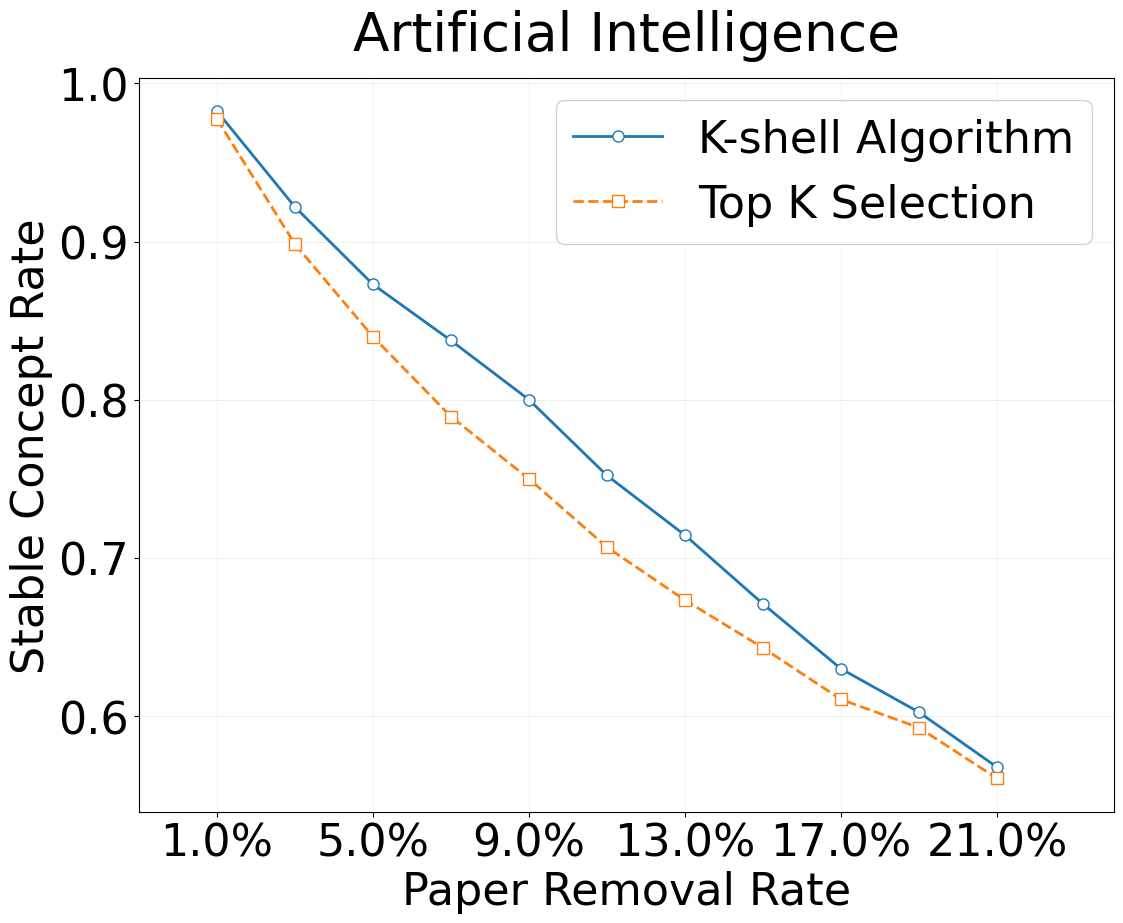

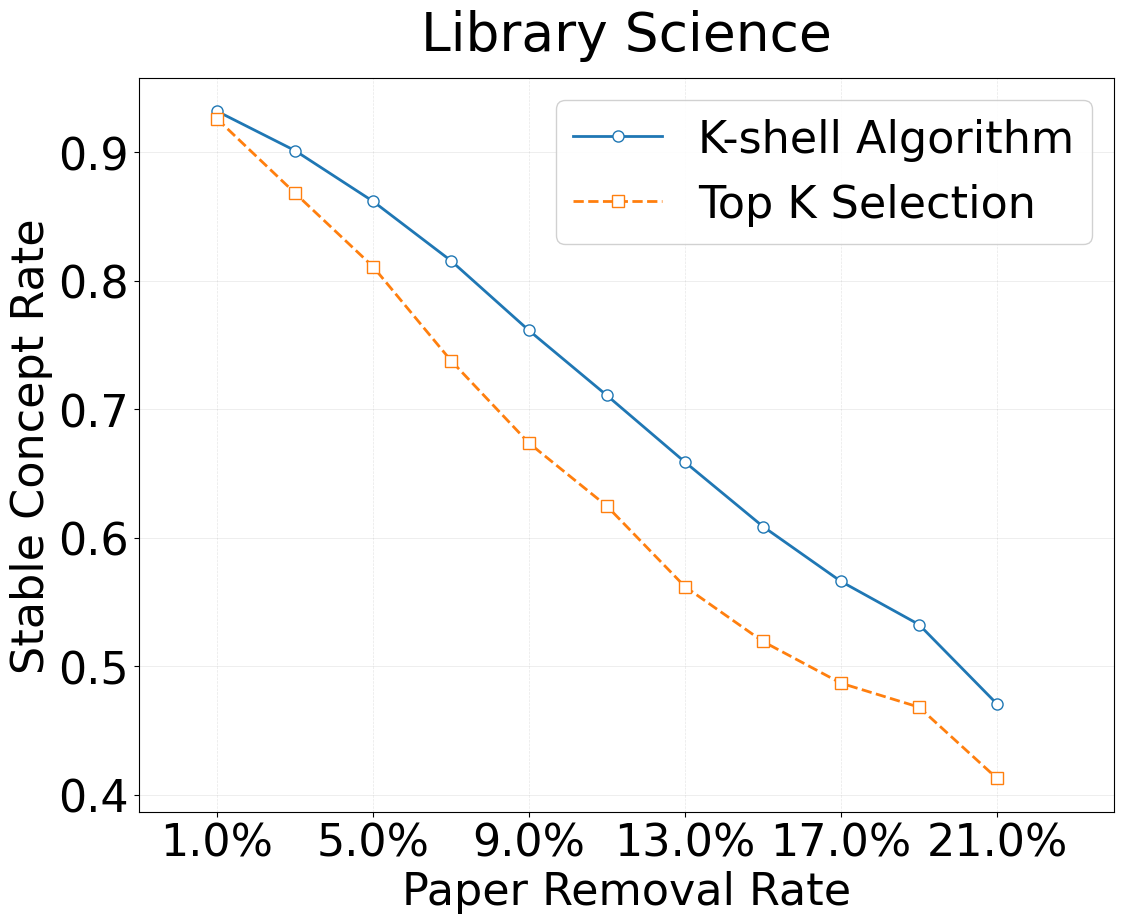

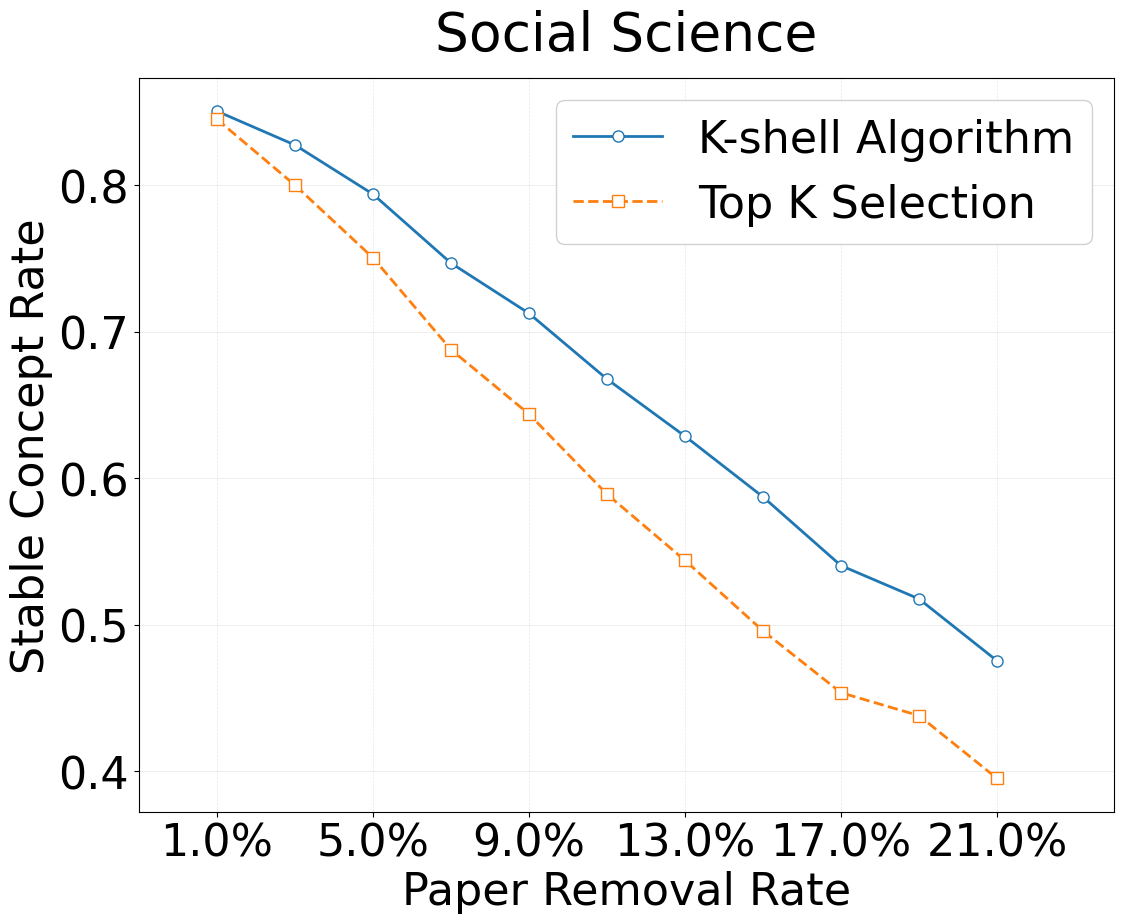

In [6]:
def analyze_stability_across_a(
    a_min=0.0,
    a_max=0.23,
    num_points=12,
    sep=5,
    t=5,
    random_seed=42,
    num_processes=None,
    file_path="topics_csr_ai",
    domain_name="Artificial Intelligence"
):
    """
    Analyze stability across different paper removal rates (a values)

    Args:
        a_min (float): Minimum removal rate (default=0.0)
        a_max (float): Maximum removal rate (default=0.21)
        num_points (int): Number of a values to test
        sep (int): Year span for time windows
        t (int): Number of simulation runs per window
        random_seed (int): Base random seed
        num_processes (int): Number of parallel processes
        file_path (str): Which folder to import topics
        domain_name (str): Which domain is the dataset

    Returns:
        tuple: (a_values, k_shell_means, dc_means)
    """
    # Generate a values with logarithmic spacing near 0
    # a_values = np.logspace(np.log10(0.01), np.log10(a_max), num_points)
    a_values = np.arange(0.01, a_max, (a_max - 0.01) / (num_points - 1))
    a_values = np.unique(np.sort(a_values))[:num_points]

    # Initialize result containers
    k_shell_means = []
    dc_means = []

    for a in a_values:
        print(f"Processing a={a:.4f}")
        results = run_stability_analysis(
            a=a,
            t=t,
            sep=sep,
            random_seed=random_seed,
            num_processes=num_processes,
            file_path=file_path,
        )

        k_shell_means.append(results["k_shell"]["mean"])
        dc_means.append(results["dynamic_count"]["mean"])

    # Convert to numpy arrays
    a_values = np.array(a_values)
    k_shell_means = np.array(k_shell_means)
    dc_means = np.array(dc_means)

    # Create plot with improved formatting
    plt.figure(figsize=(12, 10))
    plt.rcParams.update({"font.size": 32})

    # Plot mean stability
    plt.plot(
        a_values,
        k_shell_means,
        "-o",
        markersize=8,
        label="K-shell Algorithm",
        color="#1f77b4",
        linewidth=2,
        markerfacecolor="white",
        markeredgecolor="#1f77b4",
    )
    plt.plot(
        a_values,
        dc_means,
        "--s",
        markersize=8,
        label="Top K Selection",
        color="#ff7f0e",
        linewidth=2,
        markerfacecolor="white",
        markeredgecolor="#ff7f0e",
    )

    # Formatting
    plt.title(
        f"{domain_name}", pad=20
    )
    plt.xlabel("Paper Removal Rate")
    plt.ylabel("Stable Concept Rate")
    plt.legend(frameon=True, framealpha=0.9, loc="best")

    # Custom grid and ticks
    plt.xticks(a_values[::2], [f"{x:.1%}" for x in a_values][::2], rotation=0)
    plt.gca().xaxis.set_ticks_position("bottom")
    plt.gca().yaxis.set_ticks_position("left")

    # Add vertical grid lines at each data point
    plt.grid(axis="x", alpha=0.3, linestyle="--", linewidth=0.5)
    plt.grid(axis="y", alpha=0.3, linestyle="-", linewidth=0.5)

    # Set axis limits
    plt.xlim(a_min - 0.01, a_max + 0.01)

    # Show plot
    plt.tight_layout()
    plt.savefig(f"./pic_for_paper/3.2 - K-shell {file_path}.pdf")

    return a_values, k_shell_means, dc_means

def compare(a_values, k_shell_means, dc_means):
    diff = k_shell_means - dc_means
    print("min:", min(diff))
    print("max:", max(diff))
    print("avg:", np.average(diff))
    a_range = (a_values[-1] - a_values[0]) * 10
    print(f"slope: K-shell {(k_shell_means[-1] - k_shell_means[0]) / a_range}, \
    Baseline: {(dc_means[-1] - dc_means[0]) / a_range}")


a_values, k_shell_means, dc_means = analyze_stability_across_a(
    t=5, file_path="topics_csr_ai", domain_name="Artificial Intelligence"
)
compare(a_values, k_shell_means, dc_means)
a_values, k_shell_means, dc_means = analyze_stability_across_a(
    t=5, file_path="topics_lis", domain_name="Library Science"
)
compare(a_values, k_shell_means, dc_means)
a_values, k_shell_means, dc_means = analyze_stability_across_a(
    t=5, file_path="topics_soci", domain_name="Social Science"
)
compare(a_values, k_shell_means, dc_means)